<a href="https://colab.research.google.com/github/hsssj4/2026-1_CV/blob/main/11%EC%A3%BC%EC%B0%A8_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#실험 공통 설정



# [Cell 1] import library

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# visualizaiton
%matplotlib inline
plt.rcParams['axes.unicode_minus'] = False

# [Cell 2] 데이터셋 준비

In [ ]:

digits = load_digits()

# 스케일링 (학습 안정성을 위해 필수)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(digits.data)

# PyTorch Tensor로 변환
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(digits.target, dtype=torch.long)

# Train / Test 분할 (8:2)
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

print(f"Train data shape: {X_train.shape}, Test data shape: {X_test.shape}")

Train data shape: torch.Size([1437, 64]), Test data shape: torch.Size([360, 64])


# [Cell 3] 다층 퍼셉트론(MLP) 모델 정의

In [ ]:

class MLP(nn.Module):
    def __init__(self, activation_fn=nn.ReLU):
        super(MLP, self).__init__()
        # 입력층(64) -> 은닉층1(256) -> 은닉층2(128) -> 출력층(10)
        self.fc1 = nn.Linear(64, 256)
        self.act1 = activation_fn()
        self.fc2 = nn.Linear(256, 128)
        self.act2 = activation_fn()
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        x = self.fc3(x)
        return x

# [Cell 4] 모델 학습 및 내부 데이터 추출 마스터 함수

In [ ]:
def train_and_analyze(loss_type, activation_fn=nn.ReLU, optimizer_name='SGD', epochs=100, lr=0.1):
    model = MLP(activation_fn)

    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr)

    if 'MSE' in loss_type:
        criterion = nn.MSELoss()
    else:
        criterion = nn.CrossEntropyLoss()

    history = {
        'train_loss': [], 'train_acc': [],
        'grad_flow_fc1': [], 'grad_flow_fc2': [], 'grad_flow_fc3': [],
        'grad_out_early': None, 'grad_out_late': None
    }
    activations = {'early': [], 'mid': [], 'late': []}

    # Hook 설정 (첫 번째 은닉층의 활성화 값 캡처)
    def get_activation(epoch_phase):
        def hook(model, input, output):
            activations[epoch_phase].append(output.detach().numpy().flatten())
        return hook

    hook_handle = model.act1.register_forward_hook(get_activation('temp'))

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # 특정 에포크(초반, 중반, 후반)에서만 Activation 기록
        if epoch == 0:
            hook_handle.remove(); hook_handle = model.act1.register_forward_hook(get_activation('early'))
        elif epoch == epochs // 2:
            hook_handle.remove(); hook_handle = model.act1.register_forward_hook(get_activation('mid'))
        elif epoch == epochs - 1:
            hook_handle.remove(); hook_handle = model.act1.register_forward_hook(get_activation('late'))
        else:
            hook_handle.remove()

        outputs = model(X_train)

        # [실험 A] Loss 형태에 따른 처리
        if loss_type == 'MSE_with_Softmax':
            outputs_softmax = torch.softmax(outputs, dim=1)
            y_train_onehot = torch.zeros(y_train.size(0), 10).scatter_(1, y_train.unsqueeze(1), 1.0)
            loss = criterion(outputs_softmax, y_train_onehot)
        elif loss_type == 'MSE_no_Softmax':
            y_train_onehot = torch.zeros(y_train.size(0), 10).scatter_(1, y_train.unsqueeze(1), 1.0)
            loss = criterion(outputs, y_train_onehot)
        elif loss_type == 'CrossEntropy':
            loss = criterion(outputs, y_train)

        loss.backward()

        # 출력층 Gradient 저장 (학습 초기 vs 후반 비교용)
        output_layer_grad = model.fc3.weight.grad.clone().detach().numpy().flatten()
        if epoch == 0: history['grad_out_early'] = output_layer_grad
        elif epoch == epochs - 1: history['grad_out_late'] = output_layer_grad

        # 층별 Gradient 흐름 저장 (Vanishing 현상 추적용)
        history['grad_flow_fc1'].append(model.fc1.weight.grad.abs().mean().item())
        history['grad_flow_fc2'].append(model.fc2.weight.grad.abs().mean().item())
        history['grad_flow_fc3'].append(model.fc3.weight.grad.abs().mean().item())

        optimizer.step()

        # Loss 및 Acc 저장
        history['train_loss'].append(loss.item())
        _, predicted = torch.max(outputs, 1)
        acc = (predicted == y_train).float().mean().item() * 100
        history['train_acc'].append(acc)

    return history, activations

#[실험 A] 손실 함수 비교 학습 진행

In [ ]:

print("--- 실험 A 학습 시작 ---")
epochs_num = 100
lr_rate = 0.1

# 1. CrossEntropy
res_ce, act_ce = train_and_analyze('CrossEntropy', epochs=epochs_num, lr=lr_rate)
print("CrossEntropy 학습 완료")

# 2. MSE with Softmax
res_mse_soft, _ = train_and_analyze('MSE_with_Softmax', epochs=epochs_num, lr=lr_rate)
print("MSE w/ Softmax 학습 완료")

# 3. MSE without Softmax
res_mse_no, _ = train_and_analyze('MSE_no_Softmax', epochs=epochs_num, lr=lr_rate)
print("MSE w/o Softmax 학습 완료")
print("--- 학습 종료 ---")

--- 실험 A 학습 시작 ---
CrossEntropy 학습 완료
MSE w/ Softmax 학습 완료
MSE w/o Softmax 학습 완료
--- 학습 종료 ---


#통합 결과 시각화

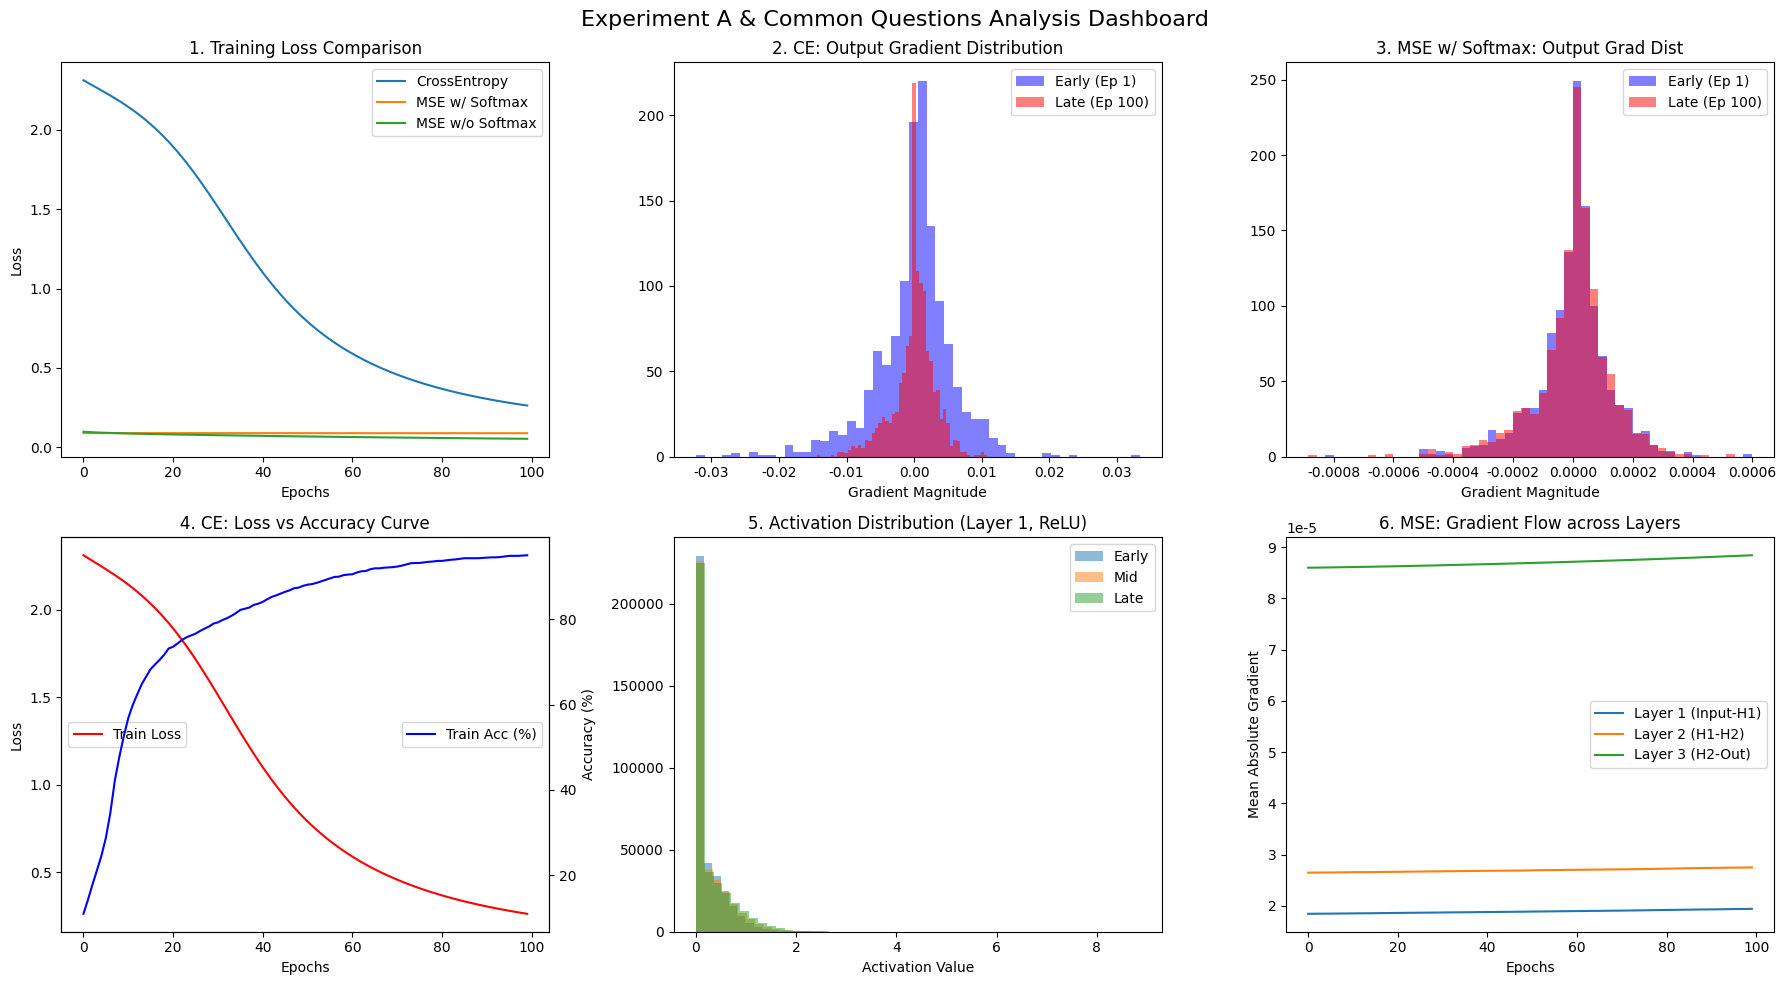

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Experiment A & Common Questions Analysis Dashboard', fontsize=16)

# 1. Loss 비교 (실험 A 1, 2, 4번)
axs[0, 0].plot(res_ce['train_loss'], label='CrossEntropy')
axs[0, 0].plot(res_mse_soft['train_loss'], label='MSE w/ Softmax')
axs[0, 0].plot(res_mse_no['train_loss'], label='MSE w/o Softmax')
axs[0, 0].set_title('1. Training Loss Comparison')
axs[0, 0].set_xlabel('Epochs'); axs[0, 0].set_ylabel('Loss'); axs[0, 0].legend()

# 2. CE Output Gradient (실험 A 3번)
axs[0, 1].hist(res_ce['grad_out_early'], bins=50, alpha=0.5, label='Early (Ep 1)', color='blue')
axs[0, 1].hist(res_ce['grad_out_late'], bins=50, alpha=0.5, label='Late (Ep 100)', color='red')
axs[0, 1].set_title('2. CE: Output Gradient Distribution')
axs[0, 1].set_xlabel('Gradient Magnitude'); axs[0, 1].legend()

# 3. MSE Output Gradient (실험 A 3번)
axs[0, 2].hist(res_mse_soft['grad_out_early'], bins=50, alpha=0.5, label='Early (Ep 1)', color='blue')
axs[0, 2].hist(res_mse_soft['grad_out_late'], bins=50, alpha=0.5, label='Late (Ep 100)', color='red')
axs[0, 2].set_title('3. MSE w/ Softmax: Output Grad Dist')
axs[0, 2].set_xlabel('Gradient Magnitude'); axs[0, 2].legend()

# 4. CE Loss vs Accuracy (공통 1, 2번)
ax4_2 = axs[1, 0].twinx()
axs[1, 0].plot(res_ce['train_loss'], label='Train Loss', color='red')
ax4_2.plot(res_ce['train_acc'], label='Train Acc (%)', color='blue')
axs[1, 0].set_title('4. CE: Loss vs Accuracy Curve')
axs[1, 0].set_xlabel('Epochs'); axs[1, 0].set_ylabel('Loss'); ax4_2.set_ylabel('Accuracy (%)')
axs[1, 0].legend(loc='center left'); ax4_2.legend(loc='center right')

# 5. CE Layer 1 Activation (공통 3번)
axs[1, 1].hist(act_ce['early'][0], bins=50, alpha=0.5, label='Early')
axs[1, 1].hist(act_ce['mid'][0], bins=50, alpha=0.5, label='Mid')
axs[1, 1].hist(act_ce['late'][0], bins=50, alpha=0.5, label='Late')
axs[1, 1].set_title('5. Activation Distribution (Layer 1, ReLU)')
axs[1, 1].set_xlabel('Activation Value'); axs[1, 1].legend()

# 6. MSE Gradient Flow (공통 4번 - Vanishing 확인)
axs[1, 2].plot(res_mse_soft['grad_flow_fc1'], label='Layer 1 (Input-H1)')
axs[1, 2].plot(res_mse_soft['grad_flow_fc2'], label='Layer 2 (H1-H2)')
axs[1, 2].plot(res_mse_soft['grad_flow_fc3'], label='Layer 3 (H2-Out)')
axs[1, 2].set_title('6. MSE: Gradient Flow across Layers')
axs[1, 2].set_xlabel('Epochs'); axs[1, 2].set_ylabel('Mean Absolute Gradient')
axs[1, 2].legend()

plt.tight_layout()
plt.show()

# [실험 B] 활성화 함수 비교 분석용 함수

In [ ]:
def train_and_analyze_exp_b(activation_name, epochs=100, lr=0.1):
    # 활성화 함수 매핑
    if activation_name == 'ReLU':
        act_fn = nn.ReLU
    elif activation_name == 'LeakyReLU':
        act_fn = nn.LeakyReLU
    elif activation_name == 'Sigmoid':
        act_fn = nn.Sigmoid

    model = MLP(act_fn)
    criterion = nn.CrossEntropyLoss() # Loss는 CE로 고정하여 활성화 함수 효과만 독립적으로 관찰
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # 기록용 딕셔너리
    history = {
        'train_loss': [], 'train_acc': [],
        'grad_flow_fc1': [], 'grad_flow_fc2': [], 'grad_flow_fc3': [],
        'dead_neuron_ratio': [], # B1, B2 질문 대응 (x <= 0 인 뉴런 비율)
        'grad_heatmap_data': []  # B4 질문 대응 (히트맵용)
    }
    activations = {'early': [], 'mid': [], 'late': []}

    # Hook 1: 특정 시점(초/중/후반)의 Activation 분포 캡처 (공통 Q3, B3 대응)
    def get_activation_dist(epoch_phase):
        def hook(model, input, output):
            activations[epoch_phase].append(output.detach().numpy().flatten())
        return hook

    # Hook 2: 매 에포크마다 Dead Neuron(0 이하로 출력되는 값) 비율 측정
    def measure_dead_neurons(model, input, output):
        out_tensor = output.detach()
        # 0 이하인 값의 비율 (ReLU에서는 완전한 Dead, LeakyReLU에서는 Negative Slope 구간)
        dead_ratio = (out_tensor <= 0).float().mean().item() * 100
        history['dead_neuron_ratio'].append(dead_ratio)

    hook_dist = model.act1.register_forward_hook(get_activation_dist('temp'))
    hook_dead = model.act1.register_forward_hook(measure_dead_neurons)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # 분포 캡처 시점 제어
        if epoch == 0:
            hook_dist.remove(); hook_dist = model.act1.register_forward_hook(get_activation_dist('early'))
        elif epoch == epochs // 2:
            hook_dist.remove(); hook_dist = model.act1.register_forward_hook(get_activation_dist('mid'))
        elif epoch == epochs - 1:
            hook_dist.remove(); hook_dist = model.act1.register_forward_hook(get_activation_dist('late'))
        else:
            hook_dist.remove()

        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()

        # [공통 Q4 & B4] Layer별 평균 Gradient 절댓값 추적 (히트맵 및 Flow용)
        grad_1 = model.fc1.weight.grad.abs().mean().item()
        grad_2 = model.fc2.weight.grad.abs().mean().item()
        grad_3 = model.fc3.weight.grad.abs().mean().item()

        history['grad_flow_fc1'].append(grad_1)
        history['grad_flow_fc2'].append(grad_2)
        history['grad_flow_fc3'].append(grad_3)
        history['grad_heatmap_data'].append([grad_1, grad_2, grad_3])

        optimizer.step()

        # Loss 및 Acc 저장
        history['train_loss'].append(loss.item())
        _, predicted = torch.max(outputs, 1)
        acc = (predicted == y_train).float().mean().item() * 100
        history['train_acc'].append(acc)

    hook_dead.remove() # 메모리 누수 방지

    # 히트맵 데이터를 (Layer수 x Epoch수) 형태로 Transpose
    history['grad_heatmap_data'] = np.array(history['grad_heatmap_data']).T

    return history, activations

In [ ]:
# [Cell 8] [실험 B] 활성화 함수 3종 학습 진행
print("--- 실험 B (활성화 함수 비교) 학습 시작 ---")
epochs_num_b = 100
lr_rate_b = 0.1

res_relu, act_relu = train_and_analyze_exp_b('ReLU', epochs=epochs_num_b, lr=lr_rate_b)
print("1. ReLU 학습 완료")

res_leaky, act_leaky = train_and_analyze_exp_b('LeakyReLU', epochs=epochs_num_b, lr=lr_rate_b)
print("2. LeakyReLU 학습 완료")

res_sig, act_sig = train_and_analyze_exp_b('Sigmoid', epochs=epochs_num_b, lr=lr_rate_b)
print("3. Sigmoid 학습 완료")
print("--- 학습 종료 ---")

--- 실험 B (활성화 함수 비교) 학습 시작 ---
1. ReLU 학습 완료
2. LeakyReLU 학습 완료
3. Sigmoid 학습 완료
--- 학습 종료 ---


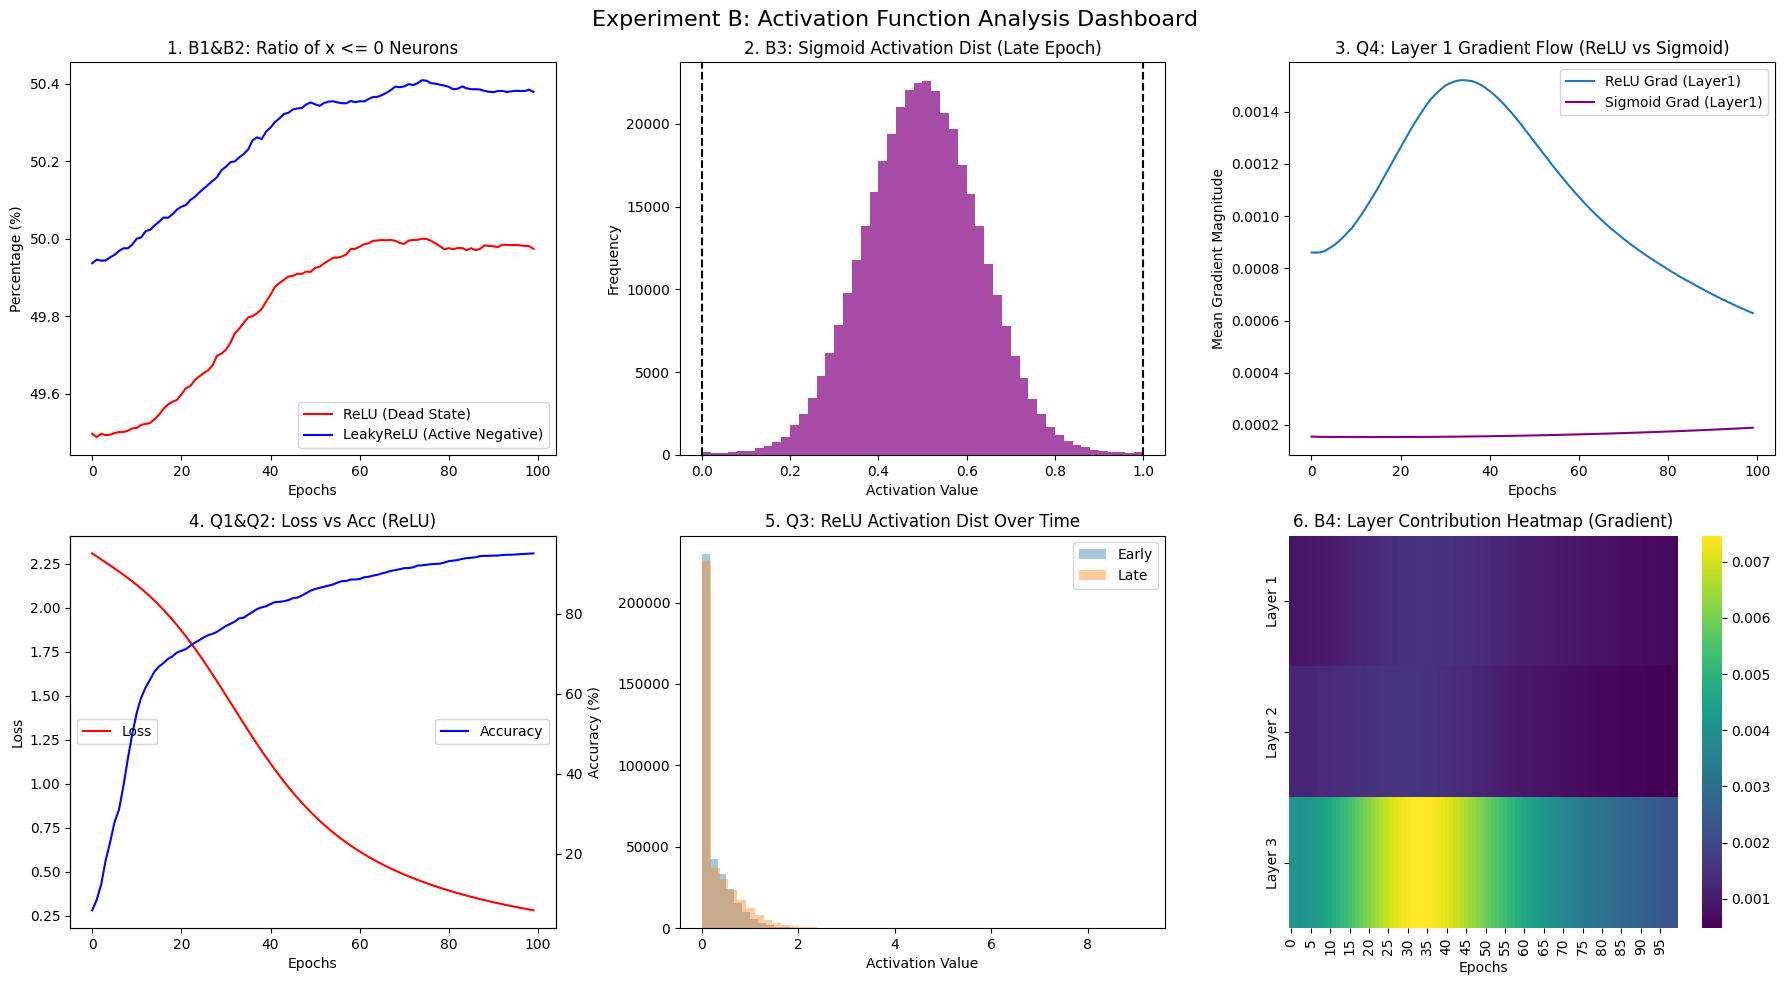

In [ ]:
# [Cell 9] 실험 B & 공통 질문 통합 분석 대시보드
import seaborn as sns # 히트맵을 위해 seaborn 사용 (없다면 pip install seaborn)

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Experiment B: Activation Function Analysis Dashboard', fontsize=16)

# [그래프 1] B1 & B2: Dead ReLU 비율 비교 (0 이하 출력 비율)
axs[0, 0].plot(res_relu['dead_neuron_ratio'], label='ReLU (Dead State)', color='red')
axs[0, 0].plot(res_leaky['dead_neuron_ratio'], label='LeakyReLU (Active Negative)', color='blue')
axs[0, 0].set_title('1. B1&B2: Ratio of x <= 0 Neurons')
axs[0, 0].set_xlabel('Epochs'); axs[0, 0].set_ylabel('Percentage (%)')
axs[0, 0].legend()

# [그래프 2] B3: Sigmoid Activation 분포 (Vanishing 원인 분석)
axs[0, 1].hist(act_sig['late'][0], bins=50, alpha=0.7, color='purple')
axs[0, 1].set_title('2. B3: Sigmoid Activation Dist (Late Epoch)')
axs[0, 1].set_xlabel('Activation Value'); axs[0, 1].set_ylabel('Frequency')
# 0과 1 근처에 수렴하는 현상(Saturating)을 강조하기 위한 세로줄
axs[0, 1].axvline(0, color='black', linestyle='--'); axs[0, 1].axvline(1, color='black', linestyle='--')

# [그래프 3] 공통 Q4 & B3: 첫 번째 Layer의 Gradient Flow 비교 (Vanishing 증명)
axs[0, 2].plot(res_relu['grad_flow_fc1'], label='ReLU Grad (Layer1)')
axs[0, 2].plot(res_sig['grad_flow_fc1'], label='Sigmoid Grad (Layer1)', color='purple')
axs[0, 2].set_title('3. Q4: Layer 1 Gradient Flow (ReLU vs Sigmoid)')
axs[0, 2].set_xlabel('Epochs'); axs[0, 2].set_ylabel('Mean Gradient Magnitude')
axs[0, 2].legend()

# [그래프 4] 공통 Q1 & Q2: Loss vs Accuracy 불균형 (ReLU 기준)
ax4_2 = axs[1, 0].twinx()
axs[1, 0].plot(res_relu['train_loss'], label='Loss', color='red')
ax4_2.plot(res_relu['train_acc'], label='Accuracy', color='blue')
axs[1, 0].set_title('4. Q1&Q2: Loss vs Acc (ReLU)')
axs[1, 0].set_xlabel('Epochs'); axs[1, 0].set_ylabel('Loss'); ax4_2.set_ylabel('Accuracy (%)')
axs[1, 0].legend(loc='center left'); ax4_2.legend(loc='center right')

# [그래프 5] 공통 Q3: ReLU의 Layer 분포 변화 (초/중/후반)
axs[1, 1].hist(act_relu['early'][0], bins=50, alpha=0.4, label='Early')
axs[1, 1].hist(act_relu['late'][0], bins=50, alpha=0.4, label='Late')
axs[1, 1].set_title('5. Q3: ReLU Activation Dist Over Time')
axs[1, 1].set_xlabel('Activation Value'); axs[1, 1].legend()

# [그래프 6] B4: 각 Layer의 학습 기여도 히트맵 (ReLU 기준)
sns.heatmap(res_relu['grad_heatmap_data'], ax=axs[1, 2], cmap='viridis',
            yticklabels=['Layer 1', 'Layer 2', 'Layer 3'])
axs[1, 2].set_title('6. B4: Layer Contribution Heatmap (Gradient)')
axs[1, 2].set_xlabel('Epochs')

plt.tight_layout()
plt.show()

#실험 C

In [ ]:
# [Cell 10] 실험 C 전용: 최적화 알고리즘 및 학습률 분석 함수
def train_and_analyze_exp_c(optimizer_name, lr=0.01, use_scheduler=False, lr_gamma=0.95, epochs=100):
    model = MLP(nn.ReLU) # 활성화 함수는 안정적인 ReLU로 고정
    criterion = nn.CrossEntropyLoss()

    # Optimizer 선택 로직 (C1, C6 질문 대응)
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'Momentum':
        # SGD에 관성(Momentum) 0.9 추가
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)

    # Learning Rate Scheduler 설정 (C4 질문 대응)
    if use_scheduler:
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_gamma)

    # 기록용 딕셔너리
    history = {
        'train_loss': [], 'train_acc': [], 'lr_rates': [],
        'grad_flow_fc1': [], 'grad_flow_fc2': [], 'grad_flow_fc3': []
    }
    activations = {'early': [], 'mid': [], 'late': []}

    # Hook: Activation 분포 캡처 (공통 Q3)
    def get_activation_dist(epoch_phase):
        def hook(model, input, output):
            activations[epoch_phase].append(output.detach().numpy().flatten())
        return hook

    hook_dist = model.act1.register_forward_hook(get_activation_dist('temp'))

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # 분포 캡처 시점 제어
        if epoch == 0:
            hook_dist.remove(); hook_dist = model.act1.register_forward_hook(get_activation_dist('early'))
        elif epoch == epochs // 2:
            hook_dist.remove(); hook_dist = model.act1.register_forward_hook(get_activation_dist('mid'))
        elif epoch == epochs - 1:
            hook_dist.remove(); hook_dist = model.act1.register_forward_hook(get_activation_dist('late'))
        else:
            hook_dist.remove()

        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()

        # [C5, 공통 Q4] Layer별 평균 Gradient 절댓값 추적
        history['grad_flow_fc1'].append(model.fc1.weight.grad.abs().mean().item())
        history['grad_flow_fc2'].append(model.fc2.weight.grad.abs().mean().item())
        history['grad_flow_fc3'].append(model.fc3.weight.grad.abs().mean().item())

        optimizer.step()

        # 스케줄러 업데이트 및 현재 LR 기록 (C4 대응)
        if use_scheduler:
            scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        history['lr_rates'].append(current_lr)

        # Loss 및 Acc 저장
        history['train_loss'].append(loss.item())
        _, predicted = torch.max(outputs, 1)
        acc = (predicted == y_train).float().mean().item() * 100
        history['train_acc'].append(acc)

    return history, activations

In [ ]:
# [Cell 11] [실험 C] 다양한 최적화 조건으로 학습 진행
print("--- 실험 C (최적화 알고리즘 & LR 비교) 학습 시작 ---")
epochs_num_c = 100

# 1. 메인 Optimizer 비교 (C1, C3, C6 대응)
# 참고: Adam은 SGD보다 보통 작은 LR(0.01)에서 최적의 성능을 냅니다.
res_sgd, _ = train_and_analyze_exp_c('SGD', lr=0.1, epochs=epochs_num_c)
res_mom, _ = train_and_analyze_exp_c('Momentum', lr=0.1, epochs=epochs_num_c)
res_adam, act_adam = train_and_analyze_exp_c('Adam', lr=0.01, epochs=epochs_num_c)
print("1. Optimizer 3종 비교 학습 완료")

# 2. 극단적인 학습률 테스트 (C2 대응)
res_sgd_large, _ = train_and_analyze_exp_c('SGD', lr=1.5, epochs=epochs_num_c) # 지나치게 큰 LR
res_sgd_small, _ = train_and_analyze_exp_c('SGD', lr=0.001, epochs=epochs_num_c) # 지나치게 작은 LR
print("2. 극단적 학습률(Overshooting/Stagnation) 학습 완료")

# 3. Learning Rate Scheduler 적용 (C4 대응)
res_adam_decay, _ = train_and_analyze_exp_c('Adam', lr=0.01, use_scheduler=True, lr_gamma=0.95, epochs=epochs_num_c)
print("3. Exponential Decay 적용 학습 완료")

print("--- 학습 종료 ---")

--- 실험 C (최적화 알고리즘 & LR 비교) 학습 시작 ---
1. Optimizer 3종 비교 학습 완료
2. 극단적 학습률(Overshooting/Stagnation) 학습 완료
3. Exponential Decay 적용 학습 완료
--- 학습 종료 ---


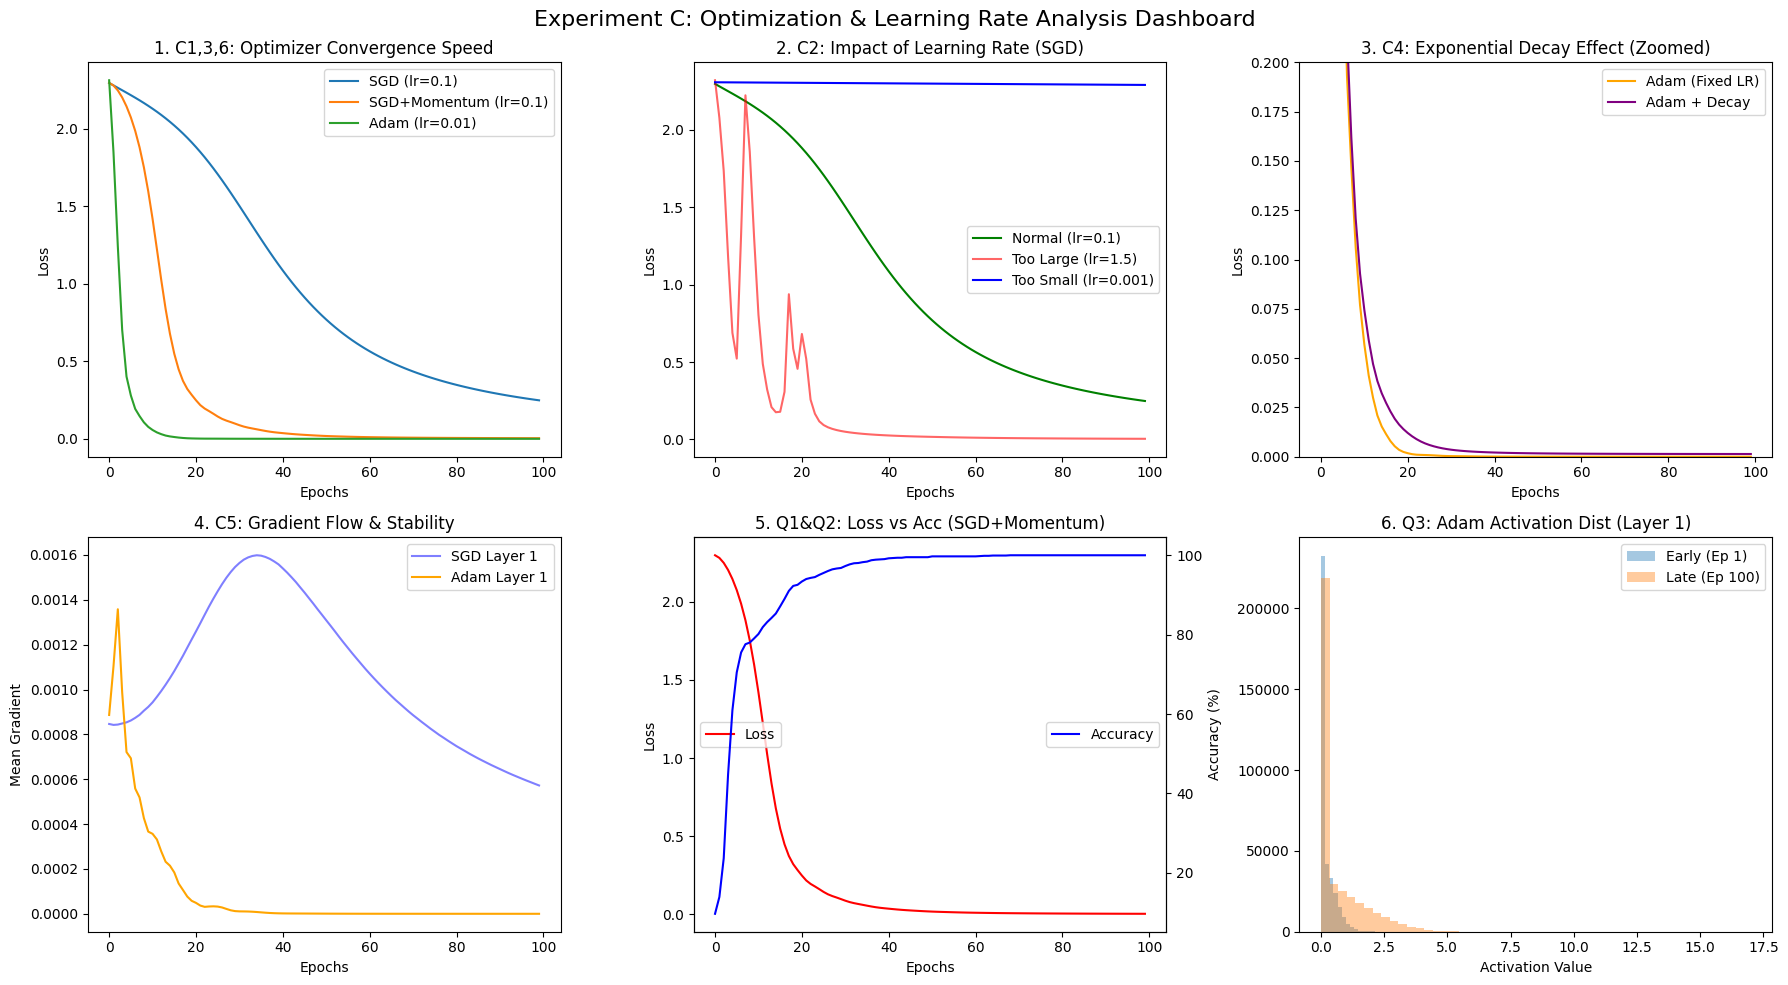

In [ ]:
# [Cell 12] 실험 C & 공통 질문 분석 대시보드
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Experiment C: Optimization & Learning Rate Analysis Dashboard', fontsize=16)

# [그래프 1] C1, C3, C6: Optimizer 3종 Loss 곡선 비교
axs[0, 0].plot(res_sgd['train_loss'], label='SGD (lr=0.1)')
axs[0, 0].plot(res_mom['train_loss'], label='SGD+Momentum (lr=0.1)')
axs[0, 0].plot(res_adam['train_loss'], label='Adam (lr=0.01)')
axs[0, 0].set_title('1. C1,3,6: Optimizer Convergence Speed')
axs[0, 0].set_xlabel('Epochs'); axs[0, 0].set_ylabel('Loss')
axs[0, 0].legend()

# [그래프 2] C2: 학습률 크기에 따른 영향 (Overshooting vs Stagnation)
axs[0, 1].plot(res_sgd['train_loss'], label='Normal (lr=0.1)', color='green')
axs[0, 1].plot(res_sgd_large['train_loss'], label='Too Large (lr=1.5)', color='red', alpha=0.6)
axs[0, 1].plot(res_sgd_small['train_loss'], label='Too Small (lr=0.001)', color='blue')
axs[0, 1].set_title('2. C2: Impact of Learning Rate (SGD)')
axs[0, 1].set_xlabel('Epochs'); axs[0, 1].set_ylabel('Loss')
axs[0, 1].legend()

# [그래프 3] C4: 지수 감소(Exponential Decay) 스케줄러 효과
axs[0, 2].plot(res_adam['train_loss'], label='Adam (Fixed LR)', color='orange')
axs[0, 2].plot(res_adam_decay['train_loss'], label='Adam + Decay', color='purple')
# 후반부 진동(Oscillation) 완화를 잘 보기 위해 Y축 범위 제한
axs[0, 2].set_ylim([0, 0.2])
axs[0, 2].set_title('3. C4: Exponential Decay Effect (Zoomed)')
axs[0, 2].set_xlabel('Epochs'); axs[0, 2].set_ylabel('Loss')
axs[0, 2].legend()

# [그래프 4] C5 & 공통 Q4: Gradient Flow 비교 (SGD vs Adam)
axs[1, 0].plot(res_sgd['grad_flow_fc1'], label='SGD Layer 1', color='blue', alpha=0.5)
axs[1, 0].plot(res_adam['grad_flow_fc1'], label='Adam Layer 1', color='orange')
axs[1, 0].set_title('4. C5: Gradient Flow & Stability')
axs[1, 0].set_xlabel('Epochs'); axs[1, 0].set_ylabel('Mean Gradient')
axs[1, 0].legend()

# [그래프 5] 공통 Q1 & Q2: Loss vs Accuracy (Momentum 기준)
ax5_2 = axs[1, 1].twinx()
axs[1, 1].plot(res_mom['train_loss'], label='Loss', color='red')
ax5_2.plot(res_mom['train_acc'], label='Accuracy', color='blue')
axs[1, 1].set_title('5. Q1&Q2: Loss vs Acc (SGD+Momentum)')
axs[1, 1].set_xlabel('Epochs'); axs[1, 1].set_ylabel('Loss'); ax5_2.set_ylabel('Accuracy (%)')
axs[1, 1].legend(loc='center left'); ax5_2.legend(loc='center right')

# [그래프 6] 공통 Q3: Adam의 Layer Activation 분포 변화
axs[1, 2].hist(act_adam['early'][0], bins=50, alpha=0.4, label='Early (Ep 1)')
axs[1, 2].hist(act_adam['late'][0], bins=50, alpha=0.4, label='Late (Ep 100)')
axs[1, 2].set_title('6. Q3: Adam Activation Dist (Layer 1)')
axs[1, 2].set_xlabel('Activation Value'); axs[1, 2].legend()

plt.tight_layout()
plt.show()